⚙️ Training Models & Comparing Metrics...

📊 MODEL COMPARISON TABLE
                     Accuracy  Precision    Recall  F1-Score
Model                                                       
Naive Bayes          0.990342   0.981685  0.978102  0.979890
Logistic Regression  0.985075   0.988593  0.948905  0.968343
Random Forest        0.986831   0.988679  0.956204  0.972171

🏆 WINNER MODEL: Naive Bayes


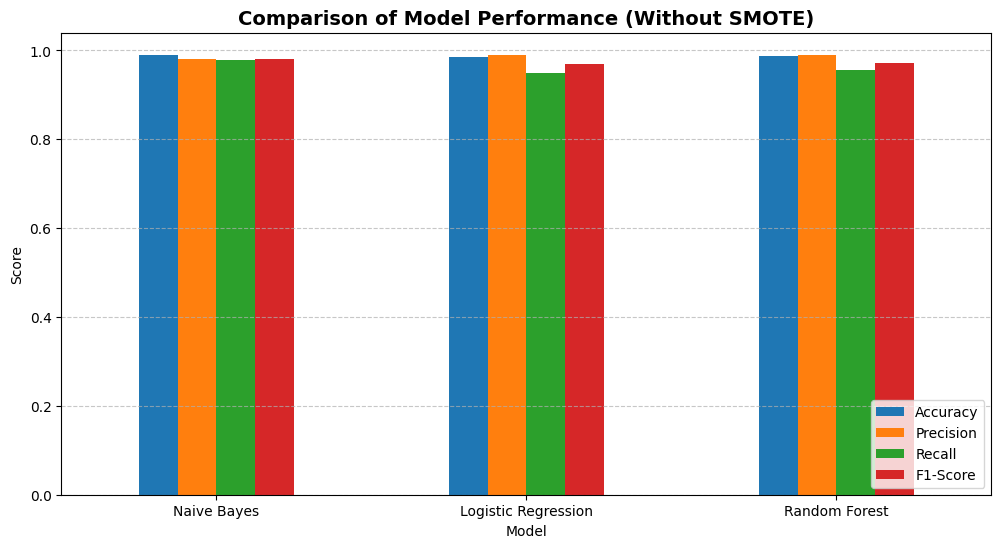


🤖 SYSTEM ACTIVE: Naive Bayes (Threshold: 0.40)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    recall_score,
    confusion_matrix,
    roc_curve,
    auc
)

warnings.filterwarnings("ignore")

# =====================================================
# 1. LOAD DATA
# =====================================================
try:
    df = pd.read_csv("emails.csv")
    df.drop_duplicates(inplace=True)
    df.dropna(inplace=True)
except:
    print("❌ emails.csv file not found")
    exit()

# =====================================================
# 2. CLEAN TEXT
# =====================================================
def clean_text(text):
    text = re.sub(r"^Subject:\s*", "", str(text).lower())
    text = re.sub(r"\W", " ", text)
    return " ".join(text.split())

df["text"] = df["text"].apply(clean_text)

# =====================================================
# 3. TF-IDF
# =====================================================
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df["text"])
y = df["spam"].values

# =====================================================
# 4. TRAIN TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =====================================================
# 5. MODELS
# =====================================================
models = {
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(solver="liblinear"),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

results = []
trained_models = {}

print("⚙️ Training Models...\n")

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rec = recall_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Recall": rec
    })

    trained_models[name] = model

# =====================================================
# 6. PERFORMANCE TABLE
# =====================================================
perf_df = pd.DataFrame(results).set_index("Model")

print("=" * 50)
print("📊 MODEL COMPARISON USING RECALL")
print("=" * 50)
print(perf_df)

# =====================================================
# 7. WINNER MODEL
# =====================================================
best_model_name = perf_df["Recall"].idxmax()
best_model = trained_models[best_model_name]

print(f"\n🏆 WINNER MODEL BASED ON RECALL: {best_model_name}")


import joblib

joblib.dump(best_model, "spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# =====================================================
# 8. GRAPH 1 - RECALL COMPARISON
# =====================================================
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=perf_df.index,
    y=perf_df["Recall"].values
)

for i, val in enumerate(perf_df["Recall"].values):
    ax.text(i, val + 0.01, round(val, 3), ha="center")

plt.title("Recall Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Recall Score")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# =====================================================
# 9. GRAPH 2 - CONFUSION MATRIX
# =====================================================
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =====================================================
# 10. GRAPH 3 - ROC CURVE
# =====================================================
y_probs = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title(f"ROC Curve - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# =====================================================
# 11. GRAPH 4 - TOP WORDS (ONLY IF NB WINS)
# =====================================================
if best_model_name == "Naive Bayes":

    feature_names = np.array(tfidf.get_feature_names_out())

    spam_idx = np.argsort(best_model.feature_log_prob_[1])[-15:]
    ham_idx = np.argsort(best_model.feature_log_prob_[0])[-15:]

    spam_words = feature_names[spam_idx]
    ham_words = feature_names[ham_idx]

    # Spam Words Graph
    plt.figure(figsize=(10, 6))
    plt.barh(spam_words, range(1, len(spam_words)+1))
    plt.title("Top Spam Words")
    plt.xlabel("Importance")
    plt.show()

    # Ham Words Graph
    plt.figure(figsize=(10, 6))
    plt.barh(ham_words, range(1, len(ham_words)+1))
    plt.title("Top Ham Words")
    plt.xlabel("Importance")
    plt.show()

# =====================================================
# 12. LIVE PREDICTION
# =====================================================
print("\n" + "=" * 50)
print(f"🤖 SYSTEM ACTIVE: {best_model_name}")
print("Primary Metric: Recall")
print("Threshold = 0.40")
print("=" * 50)

while True:

    msg = input("\nEnter Email Text (or type exit): ")

    if msg.lower() == "exit":
        print("👋 Exiting System")
        break

    vec = tfidf.transform([clean_text(msg)])

    prob_spam = best_model.predict_proba(vec)[0][1]

    if prob_spam >= 0.40:
        print(f"🚨 SPAM ({prob_spam:.2%})")
    else:
        print(f"✅ HAM ({1-prob_spam:.2%})")